# Experiment 05 — Temporal Calibration Robustness

Implements the frozen preregistered specification
`experiments/README_05_temporal_calibration_robustness.md` (**v1.1**) exactly. E05 is a
controlled follow-up to Experiment 04 whose **only** methodological change is the
conformal calibration's treatment of temporal dependence.

**Research question.** Does the replacement-vs-additive behavior observed in E04
remain when conformal calibration explicitly accounts for temporal dependence?

**Frozen 2x2 inferential design** (everything else identical to E04):

| | C0 pointwise (k = 1038) | C1 block-aware (k_block = 12) |
|---|---|---|
| **M2 scaled additive** | C0-M2 | C1-M2 |
| **M3 replacement** | C0-M3 | C1-M3 |

**C1 scope (frozen v1.1):** C1 applies **only** to M2 and M3. M0 is calibration-free;
M1 and the oracle diagnostics are evaluated under C0 pointwise calibration only, as
E04 baselines/diagnostics; no block-aware variants are computed for them.

**Frozen from E04:** P = 96 (40/8/40/8 cycle), warm-up = 128, L = 32, alpha = 0.10,
n_cal = 1152, D1/D2/D3/Test = 5952/2400/1152/2400, R = 30 with seeds
1000 + replication_id, the exact DGP, features, Quantile LSTM (1 layer, hidden 32,
phase-concat, Linear(34, 2), pinball(0.10, 0.90), Adam 1e-3, 40 full-batch epochs, no
normalization), the causal local scale std(y_{t-32:t-1}; ddof=0), and the causal
boundary-crossing window construction. Only \(q\) changes between C0 and C1.

**C1 construction (deliberately conservative).** Fixed non-overlapping chronological
blocks of \(B = 96\) = one complete cycle; the 1,152 calibration scores collapse to
12 block maxima \(S_b^{\text{block}}=\max_{i\in b} S_i\); the threshold is the
\(k_{\text{block}} = \lceil 13\times0.90\rceil = 12\)-th ordered block score. Because
the 12 blocks partition all 1,152 scores, the threshold **equals the maximum
individual calibration score** — an exact identity asserted in code. This coarseness
is a design property, not an implementation error.

**Scope statements.** No iid split-conformal validity is claimed and no formal
coverage guarantee under dependence is claimed; this is an empirical chronological
time-series evaluation. Oracle results are diagnostics. Hypotheses H1-H4 (README v1.1,
Section 12) are empirical and rejectable. Results must be attributed to calibration
strategy, interval geometry, or local-scale estimation explicitly — never silently.


In [1]:
import os

# Execution-environment note (E04-documented fix; README v1.1 Section 20): this
# Anaconda environment links MKL into NumPy while PyTorch bundles its own
# libiomp5md.dll; if both OpenMP runtimes initialize, the process aborts with
# "OMP: Error #15". MKL's documented sequential threading layer prevents that.
# It is NOT the forbidden KMP_DUPLICATE_LIB_OK workaround and changes no result.
os.environ.setdefault("MKL_THREADING_LAYER", "SEQUENTIAL")

import json
import math
import platform
import random
import subprocess
import sys
import time
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

REPO_ROOT = Path.cwd()
if not ((REPO_ROOT / "experiments").exists() and (REPO_ROOT / "results").exists()):
    REPO_ROOT = REPO_ROOT.parent
RESULTS_DIR = REPO_ROOT / "results" / "experiment_05"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cpu")

ENVIRONMENT = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "pytorch": torch.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "processor": platform.processor(),
    "device": str(DEVICE),
}
try:
    ENVIRONMENT["git_commit"] = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=REPO_ROOT, text=True).strip()
except Exception:
    ENVIRONMENT["git_commit"] = "unavailable"

print(pd.Series(ENVIRONMENT, name="environment").to_string())

python                                                   3.13.5
numpy                                                     2.1.3
pandas                                                    2.2.3
pytorch                                              2.10.0+cpu
matplotlib                                               3.10.0
platform                              Windows-11-10.0.26200-SP0
processor     Intel64 Family 6 Model 154 Stepping 4, Genuine...
device                                                      cpu
git_commit             311a2b0493d25c0c7428f3001d8a2a3a765ce813


## Frozen configuration (README v1.1)

Identical to E04 except for the block-aware calibration constants
(\(B = 96\), \(n_{\text{block}} = 12\), \(k_{\text{block}} = 12\)). Stored in the
notebook metadata and `results/experiment_05/config.json`.

In [2]:
# ================= FROZEN CONFIGURATION (README v1.1) =================
# Data-generating process (identical to E04)
P = 96
LOW_SIGMA, HIGH_SIGMA = 0.2, 1.0
N_LOW, N_UP, N_HIGH, N_DOWN = 40, 8, 40, 8
assert N_LOW + N_UP + N_HIGH + N_DOWN == P

N_WARMUP = 128
SEGMENT_CYCLES = {"D1_train": 54, "D1_val": 8, "D2": 25, "D3": 12, "Test": 25}

SEQ_LEN = 32
N_PHASE = 2
SCALE_DDOF = 0

ALPHA = 0.10
N_CAL = SEGMENT_CYCLES["D3"] * P                    # 1152
K_POINTWISE = math.ceil((N_CAL + 1) * (1.0 - ALPHA))  # 1038 (E04 convention)
assert N_CAL == 1152 and K_POINTWISE == 1038

# Block-aware calibration (E05-only constants, frozen v1.1)
BLOCK_LEN = 96                    # one complete heteroskedastic cycle
N_BLOCKS = N_CAL // BLOCK_LEN     # 1152 / 96 = 12 complete blocks
K_BLOCK = math.ceil((N_BLOCKS + 1) * (1.0 - ALPHA))   # ceil(13 * 0.90) = 12
assert N_BLOCKS == 12 and K_BLOCK == 12

HIDDEN_SIZE, NUM_LAYERS = 32, 1
LR, EPOCHS = 1e-3, 40
QUANTILES = (0.10, 0.90)

N_REPS = 30
REPLICATION_SEEDS = [1000 + r for r in range(N_REPS)]

FROZEN_CONFIG = {
    "spec": "experiments/README_05_temporal_calibration_robustness.md (v1.1, preregistered)",
    "P_cycle": P, "plateau_slots": {"low": N_LOW, "up_ramp": N_UP, "high": N_HIGH, "down_ramp": N_DOWN},
    "low_sigma": LOW_SIGMA, "high_sigma": HIGH_SIGMA,
    "transition_profile": "raised cosine at strictly interior fractions m/9, m=1..8",
    "warmup": N_WARMUP, "segments_cycles": SEGMENT_CYCLES,
    "sequence_length": SEQ_LEN, "scale_window": SEQ_LEN, "scale_ddof": SCALE_DDOF,
    "alpha": ALPHA, "n_cal": N_CAL, "k_pointwise": K_POINTWISE,
    "block_length": BLOCK_LEN, "n_blocks": N_BLOCKS, "k_block": K_BLOCK,
    "block_score": "max of the 96 scores within each chronological block (conservative)",
    "c1_scope": "C1 applies only to M2 and M3 (frozen v1.1); M1/oracles are C0-only",
    "hidden_size": HIDDEN_SIZE, "num_layers": NUM_LAYERS, "lr": LR, "epochs": EPOCHS,
    "quantiles": list(QUANTILES), "optimizer": "Adam", "full_batch": True,
    "input_normalization": "none",
    "n_replications": N_REPS, "replication_seeds": REPLICATION_SEEDS,
    "seed_rule": "replication_seed = 1000 + replication_id (0-based ids)",
    "primary_metrics": ["coverage", "mean_width", "low_coverage", "high_coverage",
                        "width_ratio", "coverage_imbalance"],
    "paired_contrasts": ["M3 - M2 under C0", "M3 - M2 under C1",
                         "C1 - C0 for M2", "C1 - C0 for M3"],
    "paired_metrics": "six primary metrics plus the Winkler score",
    "median_width": "excluded from frozen E05 summaries (v1.1)",
}
print(json.dumps(FROZEN_CONFIG, indent=2))

{
  "spec": "experiments/README_05_temporal_calibration_robustness.md (v1.1, preregistered)",
  "P_cycle": 96,
  "plateau_slots": {
    "low": 40,
    "up_ramp": 8,
    "high": 40,
    "down_ramp": 8
  },
  "low_sigma": 0.2,
  "high_sigma": 1.0,
  "transition_profile": "raised cosine at strictly interior fractions m/9, m=1..8",
  "warmup": 128,
  "segments_cycles": {
    "D1_train": 54,
    "D1_val": 8,
    "D2": 25,
    "D3": 12,
    "Test": 25
  },
  "sequence_length": 32,
  "scale_window": 32,
  "scale_ddof": 0,
  "alpha": 0.1,
  "n_cal": 1152,
  "k_pointwise": 1038,
  "block_length": 96,
  "n_blocks": 12,
  "k_block": 12,
  "block_score": "max of the 96 scores within each chronological block (conservative)",
  "c1_scope": "C1 applies only to M2 and M3 (frozen v1.1); M1/oracles are C0-only",
  "hidden_size": 32,
  "num_layers": 1,
  "lr": 0.001,
  "epochs": 40,
  "quantiles": [
    0.1,
    0.9
  ],
  "optimizer": "Adam",
  "full_batch": true,
  "input_normalization": "none",
  "n_r

## Data-generating process (identical to E04)

\[
\phi_t = (t \bmod 96)/96,\quad
f(\phi) = \sin(2\pi\phi) + 0.5\cos(4\pi\phi),\quad
y_t = f(\phi_t) + \sigma(\phi_t)\,\epsilon_t,
\]
with \(\epsilon_t\sim\mathcal N(0,1)\) iid and the exact 40/8/40/8 cycle noise
geometry (raised cosine at strictly interior fractions \(m/9\), \(m=1,\ldots,8\)).
Regime labels are mutually exclusive and evaluation-only.

In [3]:
# --- frozen DGP (identical to E04) --------------------------------------
def raised_cosine(m):
    return (1.0 - np.cos(np.pi * np.asarray(m, dtype=float) / 9.0)) / 2.0

SIGMA_CYCLE = np.empty(P)
SIGMA_CYCLE[:N_LOW] = LOW_SIGMA
SIGMA_CYCLE[N_LOW:N_LOW + N_UP] = LOW_SIGMA + (HIGH_SIGMA - LOW_SIGMA) * raised_cosine(np.arange(1, N_UP + 1))
SIGMA_CYCLE[N_LOW + N_UP:N_LOW + N_UP + N_HIGH] = HIGH_SIGMA
SIGMA_CYCLE[N_LOW + N_UP + N_HIGH:] = HIGH_SIGMA - (HIGH_SIGMA - LOW_SIGMA) * raised_cosine(np.arange(1, N_DOWN + 1))

REGIME_LOW, REGIME_RAMP, REGIME_HIGH = 0, 1, 2
REGIME_CYCLE = np.full(P, REGIME_LOW, dtype=int)
REGIME_CYCLE[N_LOW:N_LOW + N_UP] = REGIME_RAMP
REGIME_CYCLE[N_LOW + N_UP:N_LOW + N_UP + N_HIGH] = REGIME_HIGH
REGIME_CYCLE[N_LOW + N_UP + N_HIGH:] = REGIME_RAMP

def signal(phi):
    return np.sin(2 * np.pi * phi) + 0.5 * np.cos(4 * np.pi * phi)

def generate_replication(seed):
    n_total = N_WARMUP + sum(c * P for c in SEGMENT_CYCLES.values())   # 12,032
    t = np.arange(n_total)
    phi = (t % P) / P
    sigma = SIGMA_CYCLE[t % P]
    regime = REGIME_CYCLE[t % P]
    rng = np.random.default_rng(seed)
    eps = rng.standard_normal(n_total)
    y = signal(phi) + sigma * eps
    return {"t": t, "phi": phi, "sigma": sigma, "regime": regime, "y": y, "seed": seed}

print("cycle sigma slots 0..95:", np.array2string(SIGMA_CYCLE, precision=3, max_line_width=100))

cycle sigma slots 0..95: [0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2
 0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2
 0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.224 0.294 0.4   0.531 0.669 0.8   0.906 0.976
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    0.976 0.906 0.8   0.669 0.531 0.4   0.294 0.224]


## Chronological segments with causal boundary-crossing windows (identical to E04)

Only target observations are assigned to segments; the 32-lag feature windows and the
32-observation local-scale windows may cross segment boundaries causally (never using
the target or the future). Warm-up observations may provide causal context but are
never evaluation targets. This preserves \(n_{\text{cal}} = 1152\) and \(k = 1038\)
exactly, and gives 12 complete calibration blocks of 96.

In [4]:
SEGMENT_BOUNDS = {}
_acc = N_WARMUP
for _name, _cycles in SEGMENT_CYCLES.items():
    SEGMENT_BOUNDS[_name] = (_acc, _acc + _cycles * P)
    _acc += _cycles * P
D3_START, D3_END = SEGMENT_BOUNDS["D3"]
print("segment bounds:", SEGMENT_BOUNDS)

def build_target_arrays(data):
    y = data["y"]
    targets = np.arange(N_WARMUP, y.size)
    lag_starts = targets - SEQ_LEN
    assert lag_starts.min() >= 0
    lag_windows = np.lib.stride_tricks.sliding_window_view(y, SEQ_LEN)[lag_starts]
    assert np.all(lag_starts + SEQ_LEN - 1 < targets), "lag window must be strictly causal"
    s = lag_windows.std(axis=1, ddof=SCALE_DDOF)
    assert np.all(s > 0)
    phase = np.stack(
        [np.sin(2 * np.pi * data["phi"][targets]),
         np.cos(2 * np.pi * data["phi"][targets])], axis=1)
    segment = np.empty(targets.size, dtype=object)
    for name, (a, b) in SEGMENT_BOUNDS.items():
        segment[(targets >= a) & (targets < b)] = name
    assert not any(pd.isna(segment))
    return {"targets": targets, "lags": lag_windows, "phase": phase, "s": s,
            "y": y[targets], "sigma": data["sigma"][targets],
            "regime": data["regime"][targets], "segment": segment}

def split_frame(frame, name):
    m = frame["segment"] == name
    return {"lags": frame["lags"][m], "phase": frame["phase"][m], "y": frame["y"][m]}

print("D3 bounds:", (D3_START, D3_END), "| blocks:",
      [(D3_START + b * BLOCK_LEN, D3_START + (b + 1) * BLOCK_LEN) for b in range(N_BLOCKS)])

segment bounds: {'D1_train': (128, 5312), 'D1_val': (5312, 6080), 'D2': (6080, 8480), 'D3': (8480, 9632), 'Test': (9632, 12032)}
D3 bounds: (8480, 9632) | blocks: [(8480, 8576), (8576, 8672), (8672, 8768), (8768, 8864), (8864, 8960), (8960, 9056), (9056, 9152), (9152, 9248), (9248, 9344), (9344, 9440), (9440, 9536), (9536, 9632)]


## Base Quantile LSTM (identical to E04, frozen)

`nn.LSTM(1, 32, 1)` over the scalar lag sequence; final hidden state concatenated
with the two target-time phase features; `nn.Linear(34, 2)` head; pinball loss at
\(\tau \in \{0.10, 0.90\}\); Adam \(10^{-3}\); 40 full-batch epochs on D1's 54
training cycles; D1's 8 validation cycles monitored as diagnostic only; no input
normalization; deterministic CPU settings. No tuning, dropout, or architecture
changes of any kind.

In [5]:
# --- frozen model and training (identical to E04) -----------------------
class QuantileLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, n_phase=N_PHASE):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size + n_phase, 2)

    def forward(self, lags, phase):
        out, _ = self.lstm(lags)
        h = out[:, -1, :]
        return self.head(torch.cat([h, phase], dim=1))

def pinball_loss(prediction, target, quantiles=QUANTILES):
    losses = []
    for column, tau in enumerate(quantiles):
        error = target - prediction[:, column]
        losses.append(torch.maximum((tau - 1) * error, tau * error))
    return torch.stack(losses, dim=1).mean()

def train_quantile_lstm(train_part, val_part, seed):
    torch.manual_seed(seed)
    model = QuantileLSTM().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    X  = torch.as_tensor(train_part["lags"], dtype=torch.float32, device=DEVICE).unsqueeze(-1)
    PH = torch.as_tensor(train_part["phase"], dtype=torch.float32, device=DEVICE)
    Y  = torch.as_tensor(train_part["y"], dtype=torch.float32, device=DEVICE)
    model.train()
    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        loss = pinball_loss(model(X, PH), Y)
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        model.eval()
        Xv  = torch.as_tensor(val_part["lags"], dtype=torch.float32, device=DEVICE).unsqueeze(-1)
        PHv = torch.as_tensor(val_part["phase"], dtype=torch.float32, device=DEVICE)
        Yv  = torch.as_tensor(val_part["y"], dtype=torch.float32, device=DEVICE)
        val_loss = float(pinball_loss(model(Xv, PHv), Yv))
    return model, {"final_train_pinball": float(loss), "d1_val_pinball": val_loss}

def predict_quantiles(model, part):
    with torch.no_grad():
        model.eval()
        pred = model(
            torch.as_tensor(part["lags"], dtype=torch.float32, device=DEVICE).unsqueeze(-1),
            torch.as_tensor(part["phase"], dtype=torch.float32, device=DEVICE))
    return pred[:, 0].numpy().astype(np.float64), pred[:, 1].numpy().astype(np.float64)

print("QuantileLSTM parameters:", sum(p.numel() for p in QuantileLSTM().parameters()))

QuantileLSTM parameters: 4550


## Interval methods and the two calibration treatments (README v1.1, Sections 6-10)

Scores and interval geometry are **identical** across C0 and C1 — only \(q\) changes:

- **M0** raw: \([Q_L, Q_U]\) (calibration-free);
- **M1** standard CQR (C0 only): \(r_i=\max\{Q_L-y,\,y-Q_U,\,0\}\), \([Q_L-q,\,Q_U+q]\);
- **M2** scaled additive: \(S_i=r_i/s_i\), \([Q_L-q\,s_i,\ Q_U+q\,s_i]\);
- **M3** scaled center-based replacement: \(c_i=(Q_{L,i}+Q_{U,i})/2\),
  \(S_i=|y_i-c_i|/s_i\), \([c_i-q\,s_i,\ c_i+q\,s_i]\);
- **Oracle** additive/replacement (C0 diagnostics only): true \(\sigma_i\) in place
  of \(s_i\).

**C0 (pointwise):** \(k = \lceil 1153\times0.90\rceil = 1038\) on the 1,152 individual
scores (E04 convention).

**C1 (block-aware, M2/M3 only):** the 1,152 chronological calibration scores are
partitioned into \(n_{\text{block}} = 12\) non-overlapping blocks of \(B = 96\)
consecutive targets (exactly one cycle each); each block collapses to its maximum
score; \(q_{\text{block}}\) is the \(k_{\text{block}} = 12\)-th ordered block score.
Because the blocks partition all calibration scores and \(k_{\text{block}} = 12\),
the **exact identity**

\[
q_{\text{block}} \;=\; \max_{b=1}^{12} S_b^{\text{block}} \;=\; \max_{i=1}^{1152} S_i
\]

holds and is asserted in code. This deliberately conservative coarseness is a design
property (README v1.1, Section 9).

In [6]:
# --- calibration machinery (README v1.1, Sections 7-10) -----------------
def kth_ordered(scores, k):
    ordered = np.sort(np.asarray(scores, dtype=float))
    assert 1 <= k <= ordered.size
    return float(ordered[k - 1])

def conformal_quantile_pointwise(scores):
    scores = np.asarray(scores, dtype=float)
    assert scores.size == N_CAL, f"calibration size {scores.size} != frozen {N_CAL}"
    assert np.all(np.isfinite(scores))
    assert math.ceil((scores.size + 1) * (1.0 - ALPHA)) == K_POINTWISE == 1038
    return kth_ordered(scores, K_POINTWISE)

def block_partition(cal_targets):
    # chronological, non-overlapping blocks of BLOCK_LEN consecutive D3 targets
    off = np.asarray(cal_targets) - D3_START
    assert np.all((off >= 0) & (off < N_CAL)), "block targets must lie inside D3"
    block_id = off // BLOCK_LEN
    assert set(block_id.tolist()) == set(range(N_BLOCKS)), "blocks must partition D3"
    for b in range(N_BLOCKS):
        assert int((block_id == b).sum()) == BLOCK_LEN
    # block membership follows chronological order: ids are monotone in target order
    assert np.all(np.diff(block_id) >= 0)
    return block_id

def block_scores(scores, cal_targets):
    block_id = block_partition(cal_targets)
    out = np.empty(N_BLOCKS)
    for b in range(N_BLOCKS):
        members = np.asarray(scores)[block_id == b]
        assert members.size == BLOCK_LEN      # each block uses only its own 96 observations
        out[b] = members.max()
    return out

def conformal_quantile_block(scores, cal_targets):
    assert math.ceil((N_BLOCKS + 1) * (1.0 - ALPHA)) == K_BLOCK == 12
    q = kth_ordered(block_scores(scores, cal_targets), K_BLOCK)
    # EXACT IDENTITY (frozen protocol): with 12 blocks partitioning all 1152 scores
    # and k_block = 12, the block threshold is the maximum individual score.
    assert q == float(np.max(scores)), "block threshold must equal the global maximum score"
    return q

def cqr_scores(ql, qu, y):
    return np.maximum(np.maximum(ql - y, y - qu), 0.0)

def replacement_center(ql, qu):
    return (ql + qu) / 2.0

# --- interval builders (identical geometry under C0 and C1; only q changes) ---
def interval_M0(ql, qu):
    return ql.copy(), qu.copy()

def interval_M1(ql, qu, q):
    return ql - q, qu + q

def interval_M2(ql, qu, s, q_A):
    return ql - q_A * s, qu + q_A * s

def interval_M3(ql, qu, s, q_R):
    c = replacement_center(ql, qu)
    return c - q_R * s, c + q_R * s

def interval_oracle_additive(ql, qu, sigma, q_OA):
    return ql - q_OA * sigma, qu + q_OA * sigma

def interval_oracle_replacement(ql, qu, sigma, q_OR):
    c = replacement_center(ql, qu)
    return c - q_OR * sigma, c + q_OR * sigma

def calibrate_all(frame, preds):
    m = frame["segment"] == "D3"
    cal_targets = frame["targets"][m]
    y_c, s_c, sg_c = frame["y"][m], frame["s"][m], frame["sigma"][m]
    ql_c, qu_c = preds["D3"]
    c_c = replacement_center(ql_c, qu_c)
    r_c = cqr_scores(ql_c, qu_c, y_c)
    S_A, S_R = r_c / s_c, np.abs(y_c - c_c) / s_c
    qvals = {
        "q":        conformal_quantile_pointwise(r_c),        # M1 (C0 only)
        "q_A":      conformal_quantile_pointwise(S_A),         # M2 (C0)
        "q_R":      conformal_quantile_pointwise(S_R),         # M3 (C0)
        "q_OA":     conformal_quantile_pointwise(r_c / sg_c),  # oracle additive (C0 diagnostic)
        "q_OR":     conformal_quantile_pointwise(np.abs(y_c - c_c) / sg_c),  # oracle replacement
        "q_A_block": conformal_quantile_block(S_A, cal_targets),           # M2 (C1)
        "q_R_block": conformal_quantile_block(S_R, cal_targets),           # M3 (C1)
    }
    assert all(np.isfinite(v) and v >= 0.0 for v in qvals.values())
    return qvals

def build_test_intervals(frame, preds, qvals):
    m = frame["segment"] == "Test"
    y, s, sg = frame["y"][m], frame["s"][m], frame["sigma"][m]
    ql, qu = preds["Test"]
    c = replacement_center(ql, qu)
    # variant label -> (geometry, calibration, (lower, upper)); C1 strictly M2/M3
    intervals = {
        "M0 Raw Quantile":               ("M0", "none", interval_M0(ql, qu)),
        "M1 Standard CQR":               ("M1", "C0",   interval_M1(ql, qu, qvals["q"])),
        "C0-M2 Scaled Additive":         ("M2", "C0",   interval_M2(ql, qu, s, qvals["q_A"])),
        "C1-M2 Scaled Additive (block)": ("M2", "C1",   interval_M2(ql, qu, s, qvals["q_A_block"])),
        "C0-M3 Replacement":             ("M3", "C0",   interval_M3(ql, qu, s, qvals["q_R"])),
        "C1-M3 Replacement (block)":     ("M3", "C1",   interval_M3(ql, qu, s, qvals["q_R_block"])),
        "Oracle Additive (C0)":          ("OA", "C0",   interval_oracle_additive(ql, qu, sg, qvals["q_OA"])),
        "Oracle Replacement (C0)":       ("OR", "C0",   interval_oracle_replacement(ql, qu, sg, qvals["q_OR"])),
    }
    assert {g for g, c, _ in intervals.values() if c == "C1"} == {"M2", "M3"}
    return intervals, (y, s, sg, ql, qu, c)

# --- toy unit tests (no DGP involvement) --------------------------------
assert kth_ordered([3.0, 1.0, 2.0], 2) == 2.0
assert kth_ordered(np.arange(1.0, 1153.0), 1038) == 1038.0
_toy_scores = np.random.default_rng(1).standard_normal(1152)
_toy_targets = np.arange(D3_START, D3_START + N_CAL)
assert block_scores(_toy_scores, _toy_targets).size == 12
assert conformal_quantile_block(_toy_scores, _toy_targets) == float(_toy_scores.max())
_ql, _qu = np.array([0.0, 1.0]), np.array([1.0, 3.0])
_s = np.array([2.0, 0.5])
_lo, _hi = interval_M1(_ql, _qu, 0.5)
assert np.allclose(_lo, [-0.5, 0.5]) and np.allclose(_hi, [1.5, 3.5])
_lo, _hi = interval_M2(_ql, _qu, _s, 0.5)
assert np.allclose(_lo, [-1.0, 0.75]) and np.allclose(_hi, [2.0, 3.25])
_lo, _hi = interval_M3(_ql, _qu, _s, 1.0)
assert np.allclose(_lo, [-1.5, 1.5]) and np.allclose(_hi, [2.5, 2.5])
print("calibration rules: toy unit tests passed (pointwise rank, block partition,")
print("block-max identity q_block == max_i S_i, interval identities)")

calibration rules: toy unit tests passed (pointwise rank, block partition,
block-max identity q_block == max_i S_i, interval identities)


## Metrics (README v1.1, Sections 14-15)

**Primary (frozen):** overall test coverage; mean interval width; low-regime
coverage; high-regime coverage; low/high width ratio; coverage imbalance
\(|\text{cov}_{\text{high}}-\text{cov}_{\text{low}}|\) (reported once — the secondary
"low/high coverage difference" is the same quantity). The low/high mean widths are
computed as components of the ratio. **Secondary (frozen):** coverage error,
width-ratio error vs the oracle/ideal benchmark of 5, Winkler score (standard
two-sided, \(\alpha=0.10\)), ramp-regime coverage/width (diagnostic only), raw
quantile-crossing rate, Spearman(\(s_t,\sigma_t\)) scale association. Median width is
**excluded** from the frozen E05 summaries (v1.1). Width-vs-scale association can be
mechanically induced by the construction and is never evidence of adaptivity.

In [7]:
# --- metrics (README v1.1, Sections 14-15) ------------------------------
def coverage_of(lo, hi, y):
    return float(np.mean((y >= lo) & (y <= hi)))

def winkler_score(lo, hi, y, alpha=ALPHA):
    w = (hi - lo) + (2.0 / alpha) * np.maximum(0.0, lo - y) \
        + (2.0 / alpha) * np.maximum(0.0, y - hi)
    return float(np.mean(w))

def spearman_corr(a, b):
    ra = pd.Series(a).rank().to_numpy()
    rb = pd.Series(b).rank().to_numpy()
    return float(np.corrcoef(ra, rb)[0, 1])

def evaluate_intervals(lo, hi, y, regime):
    width = hi - lo
    low_m, ramp_m, high_m = regime == REGIME_LOW, regime == REGIME_RAMP, regime == REGIME_HIGH
    cov = coverage_of(lo, hi, y)
    cov_low = coverage_of(lo[low_m], hi[low_m], y[low_m])
    cov_high = coverage_of(lo[high_m], hi[high_m], y[high_m])
    w_low, w_high = float(np.mean(width[low_m])), float(np.mean(width[high_m]))
    ratio = w_high / w_low
    return {
        "coverage": cov,                                   # primary 1
        "mean_width": float(np.mean(width)),               # primary 2
        "low_coverage": cov_low,                           # primary 3
        "high_coverage": cov_high,                         # primary 4
        "width_ratio": ratio,                              # primary 5
        "coverage_imbalance": abs(cov_high - cov_low),     # primary 6 (reported once)
        "low_mean_width": w_low,                           # component of the ratio
        "high_mean_width": w_high,                         # component of the ratio
        "coverage_error": abs(cov - (1.0 - ALPHA)),        # secondary
        "width_ratio_error_vs_oracle": abs(ratio - (HIGH_SIGMA / LOW_SIGMA)),  # secondary
        "winkler": winkler_score(lo, hi, y),               # secondary
        "ramp_coverage_diag": coverage_of(lo[ramp_m], hi[ramp_m], y[ramp_m]),       # diagnostic
        "ramp_mean_width_diag": float(np.mean(width[ramp_m])),                       # diagnostic
    }

PRIMARY_METRICS = ["coverage", "mean_width", "low_coverage", "high_coverage",
                   "width_ratio", "coverage_imbalance"]
SECONDARY_METRICS = ["coverage_error", "width_ratio_error_vs_oracle", "winkler",
                     "ramp_coverage_diag", "ramp_mean_width_diag"]
SUMMARY_METRICS = PRIMARY_METRICS + SECONDARY_METRICS
PAIRED_METRICS = PRIMARY_METRICS + ["winkler"]   # frozen v1.1: 6 primary + Winkler

assert abs(winkler_score(np.array([0.0]), np.array([1.0]), np.array([2.0])) - 21.0) < 1e-9
assert abs(spearman_corr([1, 2, 3], [3, 2, 1]) + 1.0) < 1e-12
print("metric functions: toy unit tests passed (median width intentionally absent)")

metric functions: toy unit tests passed (median width intentionally absent)


## Stage 1 — single-replication validation pass (seed 1000)

All E04 structural checks plus the E05 block-aware checks — including the exact
identity \(q_{\text{block}}=\max_{b}S_b^{\text{block}}=\max_i S_i\) — must pass
before the 30-replication experiment is launched.

In [8]:
# --- Stage 1: single-replication validation pass (seed 1000) -----------
validation_log = []
def check(label, condition):
    assert condition, f"VALIDATION FAILED: {label}"
    validation_log.append(label)

t_val_start = time.perf_counter()

data_val = generate_replication(REPLICATION_SEEDS[0])
check("total generated length == 128 + 124*96 == 12032", data_val["y"].size == 12032)
check("warm-up occupies global indices 0..127 (never evaluation targets)",
      SEGMENT_BOUNDS["D1_train"][0] == N_WARMUP == 128)
check("segment boundaries [128, 5312, 6080, 8480, 9632, 12032)",
      [SEGMENT_BOUNDS[k][0] for k in ["D1_train", "D1_val", "D2", "D3", "Test"]] == [128, 5312, 6080, 8480, 9632]
      and SEGMENT_BOUNDS["Test"][1] == 12032)
check("phase alignment: every segment starts at cycle slot 32",
      all(a % P == 32 for a, _ in SEGMENT_BOUNDS.values()))

up_independent = 0.6 - 0.4 * np.cos(np.pi * np.arange(1, 9) / 9.0)
down_independent = 0.6 + 0.4 * np.cos(np.pi * np.arange(1, 9) / 9.0)
check("low plateau slots 0..39 exactly 0.2; high plateau slots 48..87 exactly 1.0",
      np.all(SIGMA_CYCLE[:40] == 0.2) and np.all(SIGMA_CYCLE[48:88] == 1.0))
check("transition slots match the algebraically independent raised-cosine form",
      np.allclose(SIGMA_CYCLE[40:48], up_independent, atol=1e-12)
      and np.allclose(SIGMA_CYCLE[88:96], down_independent, atol=1e-12))
check("transition values strictly between plateaus; exactly 40+8+40+8 slots",
      np.all((SIGMA_CYCLE[40:48] > LOW_SIGMA) & (SIGMA_CYCLE[40:48] < HIGH_SIGMA))
      and np.all((SIGMA_CYCLE[88:96] > LOW_SIGMA) & (SIGMA_CYCLE[88:96] < HIGH_SIGMA))
      and int((SIGMA_CYCLE == LOW_SIGMA).sum()) == 40 and int((SIGMA_CYCLE == HIGH_SIGMA).sum()) == 40)

frame_val = build_target_arrays(data_val)
tv = frame_val["targets"]
check("lag windows strictly causal for every target",
      np.all(tv[:, None] > (tv - SEQ_LEN)[:, None] + np.arange(SEQ_LEN)[None, :]))
check("first D1 target (t=128) uses warm-up observations 96..127 as context",
      tv[0] == 128 and tv[0] - SEQ_LEN == 96)
d3_a, d3_b = SEGMENT_BOUNDS["D3"]
test_start = SEGMENT_BOUNDS["Test"][0]
check("first D3 target lag window crosses causally into the end of D2",
      d3_a - SEQ_LEN >= SEGMENT_BOUNDS["D2"][0] and d3_a - 1 < d3_a)
check("first Test target lag window crosses causally into the end of D3",
      test_start - SEQ_LEN >= d3_a and test_start - 1 < test_start)
check("local-scale windows identical to lag windows (causal, ddof=0)",
      np.allclose(frame_val["s"][:50], frame_val["lags"][:50].std(axis=1, ddof=SCALE_DDOF), rtol=0, atol=0))

cal_m = frame_val["segment"] == "D3"
test_m = frame_val["segment"] == "Test"
cal_targets = tv[cal_m]
check("calibration size n_cal == 1152 (all D3 targets)", int(cal_m.sum()) == N_CAL == 1152)
check("calibration targets strictly precede all test targets",
      int((cal_targets < tv[test_m].min()).sum()) == N_CAL)

# --- E05 block-aware checks ---------------------------------------------
block_id = block_partition(cal_targets)
check("block length B = 96 with n_block = 12 complete blocks partitioning D3",
      BLOCK_LEN == 96 and N_BLOCKS == 12 and int((block_id == 0).sum()) == 96)
check("every block spans exactly one full cycle starting at cycle slot 32",
      all((D3_START + b * BLOCK_LEN) % P == 32 for b in range(N_BLOCKS)))
comp_ok = True
for b in range(N_BLOCKS):
    slots = (cal_targets[block_id == b] % P)
    comp = [int((REGIME_CYCLE[slots] == v).sum()) for v in (REGIME_LOW, REGIME_RAMP, REGIME_HIGH)]
    comp_ok &= comp == [40, 16, 40]
check("every block contains exactly 40 low / 16 ramp / 40 high calibration targets", comp_ok)
check("k_pointwise = ceil(1153*0.90) = 1038; k_block = ceil(13*0.90) = 12",
      K_POINTWISE == 1038 and K_BLOCK == 12)
check("calibration blocks contain no test observations",
      int((cal_targets >= test_start).sum()) == 0)

train_part, val_part = split_frame(frame_val, "D1_train"), split_frame(frame_val, "D1_val")
check("D1_train has 54*96=5184 targets and D1_val has 8*96=768 targets",
      train_part["y"].size == 5184 and val_part["y"].size == 768)
model_val, hist_val = train_quantile_lstm(train_part, val_part, REPLICATION_SEEDS[0])
preds_val = {name: predict_quantiles(model_val, split_frame(frame_val, name))
             for name in ["D2", "D3", "Test"]}
model_val2, _ = train_quantile_lstm(train_part, val_part, REPLICATION_SEEDS[0])
preds_val2 = predict_quantiles(model_val2, split_frame(frame_val, "Test"))
check("training is deterministic: same seed reproduces identical test predictions",
      np.array_equal(preds_val["Test"][0], preds_val2[0])
      and np.array_equal(preds_val["Test"][1], preds_val2[1]))

qvals_val = calibrate_all(frame_val, preds_val)
check("all seven calibrated quantiles are finite and nonnegative",
      all(np.isfinite(v) and v >= 0 for v in qvals_val.values()))

# --- the frozen exact identity ------------------------------------------
mD3 = frame_val["segment"] == "D3"
y_c = frame_val["y"][mD3]; s_c = frame_val["s"][mD3]
ql_c, qu_c = preds_val["D3"]
c_c = replacement_center(ql_c, qu_c)
S_A = cqr_scores(ql_c, qu_c, y_c) / s_c
S_R = np.abs(y_c - c_c) / s_c
check("EXACT IDENTITY: q_A_block = max_b S_b^block = max_i S_i (M2 scores)",
      qvals_val["q_A_block"] == float(S_A.max()))
check("EXACT IDENTITY: q_R_block = max_b S_b^block = max_i S_i (M3 scores)",
      qvals_val["q_R_block"] == float(S_R.max()))
check("block thresholds are at least as large as the pointwise thresholds",
      qvals_val["q_A_block"] >= qvals_val["q_A"] and qvals_val["q_R_block"] >= qvals_val["q_R"])

intervals_val, (y_t, s_t, sg_t, ql_t, qu_t, c_t) = build_test_intervals(frame_val, preds_val, qvals_val)
check("variant set is exactly the frozen 8 with C1 restricted to M2/M3",
      {g for g, c, _ in intervals_val.values() if c == "C1"} == {"M2", "M3"}
      and len(intervals_val) == 8
      and intervals_val["M1 Standard CQR"][1] == "C0"
      and intervals_val["Oracle Additive (C0)"][1] == "C0"
      and intervals_val["Oracle Replacement (C0)"][1] == "C0")
check("M0 interval is exactly [Q_L, Q_U]",
      np.array_equal(intervals_val["M0 Raw Quantile"][2][0], ql_t)
      and np.array_equal(intervals_val["M0 Raw Quantile"][2][1], qu_t))
check("C0 pointwise interval identities (M1, M2, M3)",
      np.allclose(intervals_val["M1 Standard CQR"][2][0], ql_t - qvals_val["q"], atol=1e-12)
      and np.allclose(intervals_val["C0-M2 Scaled Additive"][2][0], ql_t - qvals_val["q_A"] * s_t, atol=1e-12)
      and np.allclose(np.mean(intervals_val["C0-M3 Replacement"][2], axis=0), c_t, atol=1e-12))
check("C1 block-aware interval identities (same geometry, q replaced by q_block)",
      np.allclose(intervals_val["C1-M2 Scaled Additive (block)"][2][0], ql_t - qvals_val["q_A_block"] * s_t, atol=1e-12)
      and np.allclose(intervals_val["C1-M2 Scaled Additive (block)"][2][1], qu_t + qvals_val["q_A_block"] * s_t, atol=1e-12)
      and np.allclose(intervals_val["C1-M3 Replacement (block)"][2][0], c_t - qvals_val["q_R_block"] * s_t, atol=1e-12)
      and np.allclose(np.mean(intervals_val["C1-M3 Replacement (block)"][2], axis=0), c_t, atol=1e-12))
check("oracle intervals use true sigma (differ from the s-scaled intervals)",
      not np.allclose(intervals_val["Oracle Additive (C0)"][2][0], intervals_val["C0-M2 Scaled Additive"][2][0]))

val_seconds = time.perf_counter() - t_val_start
print(f"validation replication wall time: {val_seconds:.1f}s (two trainings)")
print("\n".join(f"  PASS  {label}" for label in validation_log))
print(f"\nALL {len(validation_log)} VALIDATION CHECKS PASSED — the 30-replication experiment may proceed.")

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_15284\2091727925.py:39: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return model, {"final_train_pinball": float(loss), "d1_val_pinball": val_loss}


validation replication wall time: 20.5s (two trainings)
  PASS  total generated length == 128 + 124*96 == 12032
  PASS  warm-up occupies global indices 0..127 (never evaluation targets)
  PASS  segment boundaries [128, 5312, 6080, 8480, 9632, 12032)
  PASS  phase alignment: every segment starts at cycle slot 32
  PASS  low plateau slots 0..39 exactly 0.2; high plateau slots 48..87 exactly 1.0
  PASS  transition slots match the algebraically independent raised-cosine form
  PASS  transition values strictly between plateaus; exactly 40+8+40+8 slots
  PASS  lag windows strictly causal for every target
  PASS  first D1 target (t=128) uses warm-up observations 96..127 as context
  PASS  first D3 target lag window crosses causally into the end of D2
  PASS  first Test target lag window crosses causally into the end of D3
  PASS  local-scale windows identical to lag windows (causal, ddof=0)
  PASS  calibration size n_cal == 1152 (all D3 targets)
  PASS  calibration targets strictly precede al

## Stage 2 — the 30-replication paired Monte Carlo experiment

For each replication id \(r = 0,\ldots,29\) with seed \(1000 + r\): one dataset, one
base Quantile LSTM, one shared set of base predictions; all **eight** result variants
(M0, M1, the four 2x2 cells C0-M2 / C1-M2 / C0-M3 / C1-M3, and the two C0 oracle
diagnostics) evaluated on the same test observations. No tuning; no D2 input into
calibration; no post-hoc changes.

In [9]:
# --- Stage 2: 30 paired replications ------------------------------------
def run_replication(rep_id):
    seed = REPLICATION_SEEDS[rep_id]
    t0 = time.perf_counter()
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    data = generate_replication(seed)
    frame = build_target_arrays(data)
    model, hist = train_quantile_lstm(split_frame(frame, "D1_train"),
                                      split_frame(frame, "D1_val"), seed)
    preds = {name: predict_quantiles(model, split_frame(frame, name))
             for name in ["D2", "D3", "Test"]}
    qvals = calibrate_all(frame, preds)
    intervals, (y_t, s_t, sg_t, ql_t, qu_t, c_t) = build_test_intervals(frame, preds, qvals)
    regime_t = frame["regime"][frame["segment"] == "Test"]

    d2_m = frame["segment"] == "D2"
    d2_raw_coverage = coverage_of(*preds["D2"], frame["y"][d2_m])
    d2_spearman = spearman_corr(frame["s"][d2_m], frame["sigma"][d2_m])
    test_spearman = spearman_corr(s_t, sg_t)
    crossing = float(np.mean(qu_t < ql_t))

    rows = []
    for label, (geometry, calibration, (lo, hi)) in intervals.items():
        rows.append({
            "replication": rep_id, "seed": seed, "variant": label,
            "geometry": geometry, "calibration": calibration,
            **evaluate_intervals(lo, hi, y_t, regime_t),
            **qvals,
            "quantile_crossing_frac_diag": crossing,
            "spearman_s_sigma_test_diag": test_spearman,
            "spearman_s_sigma_d2_diag": d2_spearman,
            "d2_raw_coverage_diag": d2_raw_coverage,
            "final_train_pinball": hist["final_train_pinball"],
            "d1_val_pinball": hist["d1_val_pinball"],
            "elapsed_s": time.perf_counter() - t0,
        })
    return rows

rep_rows = []
t_exp = time.perf_counter()
for r in range(N_REPS):
    rows = run_replication(r)
    rep_rows.extend(rows)
    if (r + 1) % 5 == 0 or r == 0:
        print(f"replication {r:2d} (seed {REPLICATION_SEEDS[r]}) done "
              f"[total {time.perf_counter() - t_exp:7.1f}s]")

replications = pd.DataFrame(rep_rows)
column_order = ["replication", "seed", "variant", "geometry", "calibration"] + SUMMARY_METRICS + \
    ["low_mean_width", "high_mean_width", "q", "q_A", "q_R", "q_OA", "q_OR", "q_A_block", "q_R_block",
     "quantile_crossing_frac_diag", "spearman_s_sigma_test_diag", "spearman_s_sigma_d2_diag",
     "d2_raw_coverage_diag", "final_train_pinball", "d1_val_pinball", "elapsed_s"]
replications = replications[column_order]
assert len(replications) == N_REPS * 8
replications.to_csv(RESULTS_DIR / "replication_results.csv", index=False)
print(f"\n{N_REPS} replications x 8 variants = {len(replications)} rows "
      f"in {time.perf_counter() - t_exp:.1f}s -> replication_results.csv")

replication  0 (seed 1000) done [total     9.5s]


replication  4 (seed 1004) done [total    47.6s]


replication  9 (seed 1009) done [total    96.3s]


replication 14 (seed 1014) done [total   145.9s]


replication 19 (seed 1019) done [total   202.5s]


replication 24 (seed 1024) done [total   258.6s]


replication 29 (seed 1029) done [total   312.9s]



30 replications x 8 variants = 240 rows in 315.9s -> replication_results.csv


## Statistical summary and pre-specified paired contrasts (README v1.1, Section 16)

Across-replication summaries use mean, standard deviation, and the t-based 95%
interval \(\bar m \pm t_{0.975,29}\,\mathrm{sd}/\sqrt{30}\) — uncertainty summaries,
not a theorem of temporal conformal validity. The four pre-specified paired contrasts
are computed on the six primary metrics plus the Winkler score:
**M3 − M2 under C0**, **M3 − M2 under C1**, **C1 − C0 for M2**, **C1 − C0 for M3**.

In [10]:
# --- summaries and contrasts (README v1.1, Section 16) ------------------
T_CRIT_975_DF29 = 2.045229642132703   # t_{0.975, df=29} (E04 frozen constant)

summary_rows = []
for variant in replications["variant"].unique():
    sub = replications[replications["variant"] == variant]
    assert len(sub) == N_REPS
    for metric in SUMMARY_METRICS:
        values = sub[metric].to_numpy()
        mean, sd = float(np.mean(values)), float(np.std(values, ddof=1))
        half = T_CRIT_975_DF29 * sd / math.sqrt(N_REPS)
        summary_rows.append({"variant": variant, "metric": metric, "mean": mean,
                             "sd": sd, "ci95_lo": mean - half, "ci95_hi": mean + half})
summary = pd.DataFrame(summary_rows)
summary.to_csv(RESULTS_DIR / "summary_results.csv", index=False)

CONTRASTS = [
    ("M3 - M2 under C0", ("M3", "C0"), ("M2", "C0")),
    ("M3 - M2 under C1", ("M3", "C1"), ("M2", "C1")),
    ("C1 - C0 for M2",   ("M2", "C1"), ("M2", "C0")),
    ("C1 - C0 for M3",   ("M3", "C1"), ("M3", "C0")),
]
paired_rows = []
for contrast, (g_hi, c_hi), (g_lo, c_lo) in CONTRASTS:
    for metric in PAIRED_METRICS:
        wide = replications.pivot(index="replication", columns=["geometry", "calibration"], values=metric)
        delta = wide[(g_hi, c_hi)].to_numpy() - wide[(g_lo, c_lo)].to_numpy()
        mean_d, sd_d = float(np.mean(delta)), float(np.std(delta, ddof=1))
        half = T_CRIT_975_DF29 * sd_d / math.sqrt(N_REPS)
        paired_rows.append({"contrast": contrast, "metric": metric, "mean_diff": mean_d,
                            "sd_diff": sd_d, "ci95_lo": mean_d - half, "ci95_hi": mean_d + half,
                            "n_replications": N_REPS, "t_crit_df29": T_CRIT_975_DF29})
paired = pd.DataFrame(paired_rows)
paired.to_csv(RESULTS_DIR / "paired_comparisons.csv", index=False)

show = summary.copy()
show["mean"] = show["mean"].map("{:.4f}".format)
show["sd"] = show["sd"].map("{:.4f}".format)
show["ci95"] = "[" + show["ci95_lo"].map("{:.4f}".format) + ", " + show["ci95_hi"].map("{:.4f}".format) + "]"
print("=== Per-variant summary across 30 replications (mean, sd, 95% t-CI) ===")
print(show[["variant", "metric", "mean", "sd", "ci95"]].to_string(index=False))
print("\n=== PRE-SPECIFIED PAIRED CONTRASTS (six primary metrics + Winkler) ===")
print(paired[["contrast", "metric", "mean_diff", "ci95_lo", "ci95_hi"]].round(4).to_string(index=False))

=== Per-variant summary across 30 replications (mean, sd, 95% t-CI) ===
                      variant                      metric    mean     sd               ci95
              M0 Raw Quantile                    coverage  0.5177 0.1961   [0.4444, 0.5909]
              M0 Raw Quantile                  mean_width  1.1248 0.4696   [0.9494, 1.3001]
              M0 Raw Quantile                low_coverage  0.7382 0.3086   [0.6229, 0.8534]
              M0 Raw Quantile               high_coverage  0.2818 0.1130   [0.2396, 0.3240]
              M0 Raw Quantile                 width_ratio  1.3005 2.2353   [0.4658, 2.1352]
              M0 Raw Quantile          coverage_imbalance  0.4729 0.2159   [0.3922, 0.5535]
              M0 Raw Quantile              coverage_error  0.3823 0.1961   [0.3091, 0.4556]
              M0 Raw Quantile width_ratio_error_vs_oracle  4.2391 0.7521   [3.9582, 4.5199]
              M0 Raw Quantile                     winkler  8.0162 1.8314   [7.3323, 8.7001]
        

## Figures (README v1.1, Section 22)

Six pre-specified figures; C0 pointwise and C1 block-aware variants are always shown
as adjacent, distinctly colored (C0 blue, C1 orange with hatching) so the calibration
strategy is never visually conflated with geometry. Oracle bars are diagnostics only.
No post-hoc figures are added.

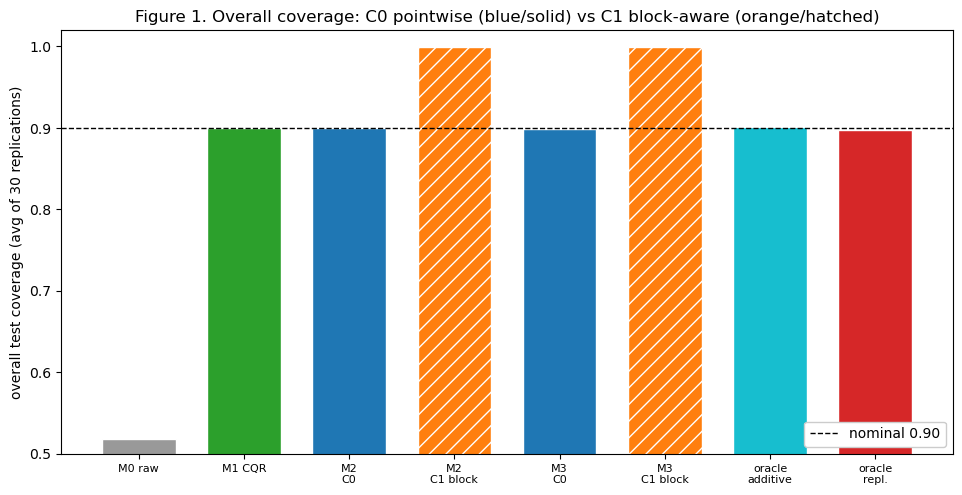

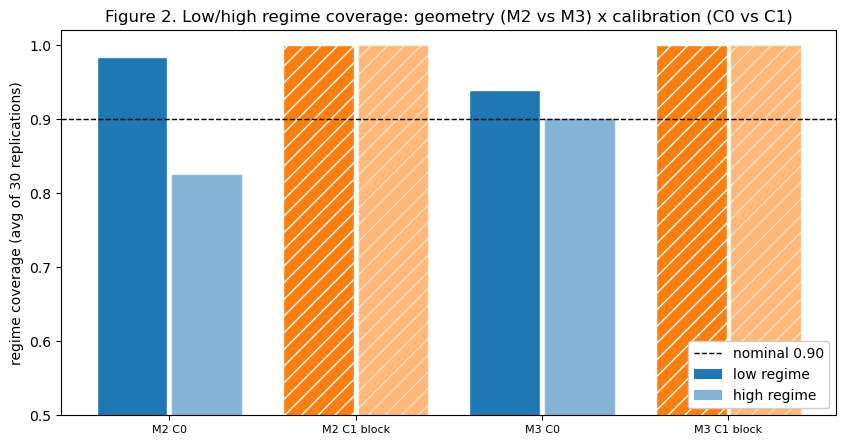

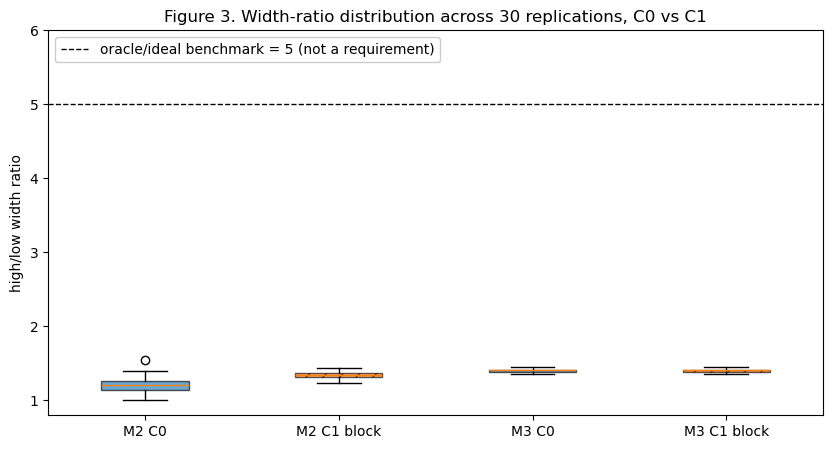

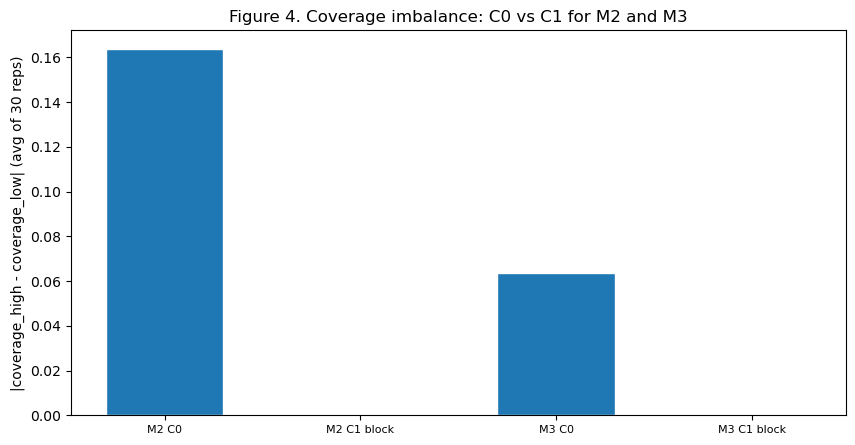

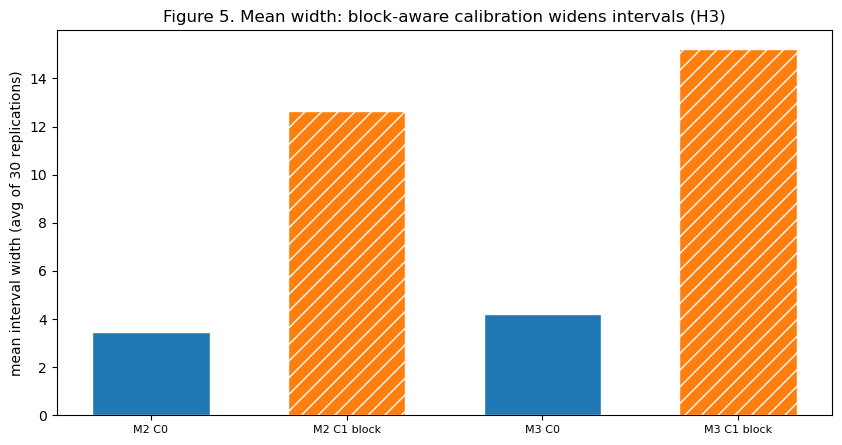

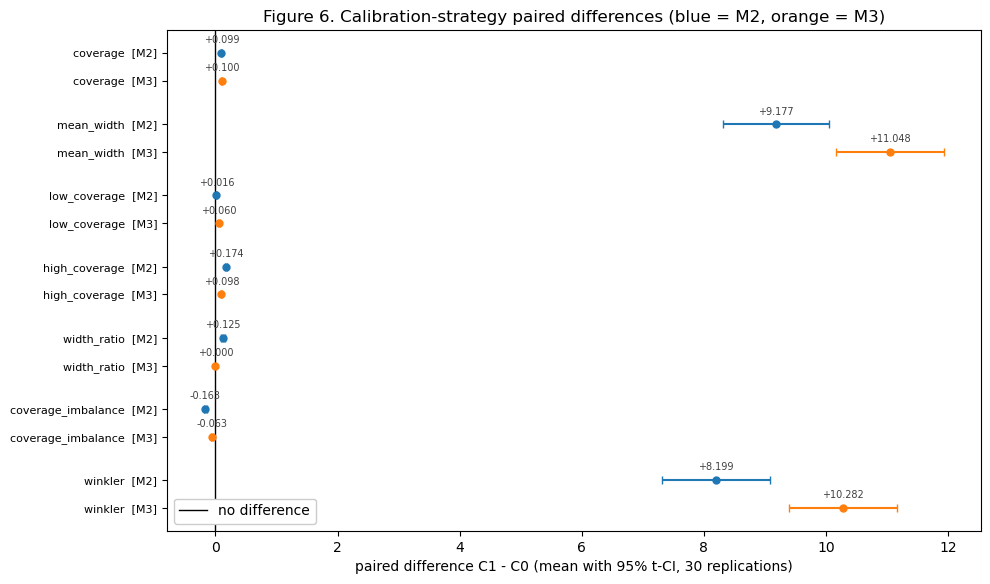

figures written to F:\notebooks\quantile-lstm-conformal-prediction\results\experiment_05\figures


In [11]:
# --- Figures 1-6 (README v1.1, Section 22) ------------------------------
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

FOUR_CELLS = ["C0-M2 Scaled Additive", "C1-M2 Scaled Additive (block)",
              "C0-M3 Replacement", "C1-M3 Replacement (block)"]
ALL_VARIANTS = ["M0 Raw Quantile", "M1 Standard CQR"] + FOUR_CELLS + \
    ["Oracle Additive (C0)", "Oracle Replacement (C0)"]
SHORT = {"M0 Raw Quantile": "M0 raw", "M1 Standard CQR": "M1 CQR",
         "C0-M2 Scaled Additive": "M2\nC0", "C1-M2 Scaled Additive (block)": "M2\nC1 block",
         "C0-M3 Replacement": "M3\nC0", "C1-M3 Replacement (block)": "M3\nC1 block",
         "Oracle Additive (C0)": "oracle\nadditive", "Oracle Replacement (C0)": "oracle\nrepl."}
VCOLOR = {"M0 Raw Quantile": "0.6", "M1 Standard CQR": "tab:green",
          "C0-M2 Scaled Additive": "tab:blue", "C1-M2 Scaled Additive (block)": "tab:orange",
          "C0-M3 Replacement": "tab:blue", "C1-M3 Replacement (block)": "tab:orange",
          "Oracle Additive (C0)": "tab:cyan", "Oracle Replacement (C0)": "tab:red"}

def savefig(fig, name):
    path = FIGURES_DIR / name
    for attempt in range(4):   # retry transient Windows file locks (AV/indexer)
        try:
            fig.savefig(path, dpi=150, bbox_inches="tight")
            break
        except OSError:
            if attempt == 3:
                raise
            time.sleep(2.0)
    plt.show(); plt.close(fig)

# ---- Figure 1: overall coverage by method and calibration strategy ------
fig, ax = plt.subplots(figsize=(11.5, 5.5))
means1 = replications.groupby("variant")["coverage"].mean()
for i, v in enumerate(ALL_VARIANTS):
    ax.bar(i, means1[v], 0.7, color=VCOLOR[v],
           hatch="//" if "(block)" in v else "", edgecolor="white")
ax.axhline(1 - ALPHA, color="k", ls="--", lw=1, label="nominal 0.90")
ax.set_xticks(range(len(ALL_VARIANTS)), [SHORT[v] for v in ALL_VARIANTS], fontsize=8)
ax.set_ylabel("overall test coverage (avg of 30 replications)")
ax.set_ylim(0.5, 1.02)
ax.set_title("Figure 1. Overall coverage: C0 pointwise (blue/solid) vs C1 block-aware (orange/hatched)")
ax.legend(loc="lower right", framealpha=1.0)
savefig(fig, "figure1_overall_coverage.png")

# ---- Figure 2: low/high regime coverage comparison ----------------------
covs = replications.groupby("variant")[["low_coverage", "high_coverage"]].mean()
fig, ax = plt.subplots(figsize=(10, 5))
for i, v in enumerate(FOUR_CELLS):
    ax.bar(i - 0.2, covs.loc[v, "low_coverage"], 0.38, color=VCOLOR[v],
           hatch="//" if "(block)" in v else "", edgecolor="white")
    ax.bar(i + 0.2, covs.loc[v, "high_coverage"], 0.38, color=VCOLOR[v], alpha=0.55,
           hatch="//" if "(block)" in v else "", edgecolor="white")
ax.axhline(1 - ALPHA, color="k", ls="--", lw=1)
legend_handles = [
    Line2D([0], [0], color="k", ls="--", lw=1, label="nominal 0.90"),
    Patch(facecolor=VCOLOR[FOUR_CELLS[0]], label="low regime"),
    Patch(facecolor=VCOLOR[FOUR_CELLS[0]], alpha=0.55, label="high regime"),
]
assert [h.get_label() for h in legend_handles] == ["nominal 0.90", "low regime", "high regime"]
ax.set_xticks(range(4), [SHORT[v].replace("\n", " ") for v in FOUR_CELLS], fontsize=8)
ax.set_ylabel("regime coverage (avg of 30 replications)")
ax.set_ylim(0.5, 1.02)
ax.set_title("Figure 2. Low/high regime coverage: geometry (M2 vs M3) x calibration (C0 vs C1)")
ax.legend(handles=legend_handles, loc="lower right", framealpha=1.0)
savefig(fig, "figure2_regime_coverage.png")

# ---- Figure 3: width ratio comparison -----------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
data_box = [replications.loc[replications["variant"] == v, "width_ratio"].to_numpy() for v in FOUR_CELLS]
bp = ax.boxplot(data_box, tick_labels=[SHORT[v].replace("\n", " ") for v in FOUR_CELLS],
                showfliers=True, patch_artist=True)
for patch, v in zip(bp["boxes"], FOUR_CELLS):
    patch.set_facecolor(VCOLOR[v]); patch.set_alpha(0.65)
    if "(block)" in v:
        patch.set_hatch("//")
ax.axhline(HIGH_SIGMA / LOW_SIGMA, color="k", ls="--", lw=1,
           label="oracle/ideal benchmark = 5 (not a requirement)")
ax.set_ylabel("high/low width ratio")
ax.set_ylim(top=max(6.0, float(np.max(np.concatenate(data_box))) * 1.08))
ax.set_title("Figure 3. Width-ratio distribution across 30 replications, C0 vs C1")
ax.legend(loc="upper left", framealpha=1.0)
savefig(fig, "figure3_width_ratio.png")

# ---- Figure 4: coverage imbalance comparison ----------------------------
imbs = replications.groupby("variant")["coverage_imbalance"].mean()
fig, ax = plt.subplots(figsize=(10, 5))
for i, v in enumerate(FOUR_CELLS):
    ax.bar(i, imbs[v], 0.6, color=VCOLOR[v],
           hatch="//" if "(block)" in v else "", edgecolor="white")
ax.set_xticks(range(4), [SHORT[v].replace("\n", " ") for v in FOUR_CELLS], fontsize=8)
ax.set_ylabel("|coverage_high - coverage_low| (avg of 30 reps)")
ax.set_title("Figure 4. Coverage imbalance: C0 vs C1 for M2 and M3")
savefig(fig, "figure4_coverage_imbalance.png")

# ---- Figure 5: mean width comparison ------------------------------------
widths = replications.groupby("variant")["mean_width"].mean()
fig, ax = plt.subplots(figsize=(10, 5))
for i, v in enumerate(FOUR_CELLS):
    ax.bar(i, widths[v], 0.6, color=VCOLOR[v],
           hatch="//" if "(block)" in v else "", edgecolor="white")
ax.set_xticks(range(4), [SHORT[v].replace("\n", " ") for v in FOUR_CELLS], fontsize=8)
ax.set_ylabel("mean interval width (avg of 30 replications)")
ax.set_title("Figure 5. Mean width: block-aware calibration widens intervals (H3)")
savefig(fig, "figure5_mean_width.png")

# ---- Figure 6: calibration-strategy paired differences (C1 - C0) --------
fig, ax = plt.subplots(figsize=(10.5, 6.5))
ylabels, yticks, ypos = [], [], 0.0
for metric in PAIRED_METRICS:
    for geometry, color in [("M2", "tab:blue"), ("M3", "tab:orange")]:
        row = paired[(paired["contrast"] == f"C1 - C0 for {geometry}") & (paired["metric"] == metric)].iloc[0]
        half = (row["ci95_hi"] - row["ci95_lo"]) / 2.0
        ax.errorbar(row["mean_diff"], ypos, xerr=[[half], [half]], fmt="o",
                    color=color, capsize=3, ms=5)
        ax.annotate(f"{row['mean_diff']:+.3f}", (row["mean_diff"], ypos),
                    xytext=(0, 7), textcoords="offset points", ha="center", fontsize=7, color="0.25")
        ylabels.append(f"{metric}  [{geometry}]"); yticks.append(ypos); ypos += 1.0
    ypos += 0.55
ax.axvline(0.0, color="k", lw=1, label="no difference")
ax.set_yticks(yticks, ylabels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("paired difference C1 - C0 (mean with 95% t-CI, 30 replications)")
ax.set_title("Figure 6. Calibration-strategy paired differences (blue = M2, orange = M3)")
ax.legend(loc="lower left", framealpha=1.0)
savefig(fig, "figure6_c1_minus_c0_paired_differences.png")

print("figures written to", FIGURES_DIR)

## Interpretation guardrails (README v1.1, Sections 17, 23)

**Attribute effects explicitly.** This design separates (1) the calibration strategy
(C1 − C0 contrasts), (2) the interval geometry (M3 − M2 contrasts under each
calibration), and (3) local-scale estimation (held fixed; association diagnostics
are mechanical because the interval construction contains \(s_t\)). Do not attribute
to replacement geometry a result actually caused by the calibration strategy.

**Known limitations, pre-declared.** The C1 threshold is the maximum of only 12
block scores — in fact the maximum of all 1,152 calibration scores — so it is
extremely coarse and conservative; this must be treated as an important limitation of
the construction, not as a defect or as a general guarantee. Marginal coverage alone
does not determine superiority; replacement is evaluated primarily on regime-level
adaptation and coverage balance; increased width must be reported as a trade-off;
the Winkler score is reported rather than omitted; oracle results are diagnostics,
not deployable methods.

**Temporal validity.** This remains an empirical chronological time-series
evaluation. No iid split-conformal validity is claimed, and taking block maxima does
not by itself establish formal coverage guarantees under dependence; formal theory is
outside the scope of E05. No post-hoc method modification is permitted based on the
observed results.

In [12]:
# --- finalize: frozen configuration + seeds in output metadata -----------
import datetime

output_record = {
    "spec": FROZEN_CONFIG["spec"],
    "notebook": "experiments/05_temporal_calibration_robustness.ipynb",
    "frozen_config": FROZEN_CONFIG,
    "replication_seeds": REPLICATION_SEEDS,
    "environment": ENVIRONMENT,
    "executed_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
    "total_wall_time_s": round(time.perf_counter() - t_exp, 1),
    "outputs": {
        "replication_results": str(RESULTS_DIR / "replication_results.csv"),
        "summary_results": str(RESULTS_DIR / "summary_results.csv"),
        "paired_comparisons": str(RESULTS_DIR / "paired_comparisons.csv"),
        "figures": sorted(p.name for p in FIGURES_DIR.glob("*.png")),
    },
    "protocol_notes": [
        "C1 scope strictly M2/M3 (frozen v1.1); M1 and oracles are C0-only",
        "block threshold identity q_block = max of all 1152 calibration scores asserted",
        "median width excluded from frozen E05 summaries (v1.1)",
        "no hyperparameter was tuned after observing results",
        "no post-hoc method modification based on observed results",
        "no iid or theorem-level conformal validity is claimed (chronological time-series protocol)",
    ],
}
with open(RESULTS_DIR / "config.json", "w", encoding="utf-8") as fh:
    json.dump(output_record, fh, indent=2)

print("Experiment 05 execution complete (results frozen; no tuning performed).")
print("\nOutput files:")
for p in sorted(RESULTS_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(REPO_ROOT)}  ({p.stat().st_size:,} bytes)")

Experiment 05 execution complete (results frozen; no tuning performed).

Output files:
  results\experiment_05\config.json  (4,222 bytes)
  results\experiment_05\figures\figure1_overall_coverage.png  (65,699 bytes)
  results\experiment_05\figures\figure2_regime_coverage.png  (69,472 bytes)
  results\experiment_05\figures\figure3_width_ratio.png  (40,049 bytes)
  results\experiment_05\figures\figure4_coverage_imbalance.png  (43,498 bytes)
  results\experiment_05\figures\figure5_mean_width.png  (46,665 bytes)
  results\experiment_05\figures\figure6_c1_minus_c0_paired_differences.png  (97,516 bytes)
  results\experiment_05\paired_comparisons.csv  (3,670 bytes)
  results\experiment_05\replication_results.csv  (115,175 bytes)
  results\experiment_05\summary_results.csv  (10,025 bytes)
